# NBA SHOT SELCTION

## Problem Statement

Task 1:-Prepare a complete data analysis report on the given data.

Task 2:- Help all stakeholders develop more effective game strategies. The  goal is to find the best model that has the highest accuracy and F1-score.

Task 3:-Our objective is to build a shot prediction model, whether the player will score or not score, based on the circumstances under which they are made into consideration


## IMPORTING LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Machine Learning prep
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# Settings
%matplotlib inline
warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the dataset (make sure the filename matches your file)
df = pd.read_csv('NBAShotSelection.csv') 

# Display the first 5 rows
df.head()

,action_type,combined_shot_type,game_event_id,game_id,lat,loc_x,loc_y,lon,minutes_remaining,period,...,shot_type,shot_zone_area,shot_zone_basic,shot_zone_range,team_id,team_name,game_date,matchup,opponent,shot_id
0,Jump Shot,Jump Shot,10,20000012,33.9723,167,72,-118.1028,10,1,...,2PT Field Goal,Right Side(R),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,1
1,Jump Shot,Jump Shot,12,20000012,34.0443,-157,0,-118.4268,10,1,...,2PT Field Goal,Left Side(L),Mid-Range,8-16 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,2
2,Jump Shot,Jump Shot,35,20000012,33.9093,-101,135,-118.3708,7,1,...,2PT Field Goal,Left Side Center(LC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,3
3,Jump Shot,Jump Shot,43,20000012,33.8693,138,175,-118.1318,6,1,...,2PT Field Goal,Right Side Center(RC),Mid-Range,16-24 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,4
4,Driving Dunk Shot,Dunk,155,20000012,34.0443,0,0,-118.2698,6,2,...,2PT Field Goal,Center(C),Restricted Area,Less Than 8 ft.,1610612747,Los Angeles Lakers,2000-10-31,LAL @ POR,POR,5


## Checking for missing values

In [6]:
# Check for missing values and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30697 entries, 0 to 30696
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   action_type         30697 non-null  object 
 1   combined_shot_type  30697 non-null  object 
 2   game_event_id       30697 non-null  int64  
 3   game_id             30697 non-null  int64  
 4   lat                 30697 non-null  float64
 5   loc_x               30697 non-null  int64  
 6   loc_y               30697 non-null  int64  
 7   lon                 30697 non-null  float64
 8   minutes_remaining   30697 non-null  int64  
 9   period              30697 non-null  int64  
 10  playoffs            30697 non-null  int64  
 11  season              30697 non-null  object 
 12  seconds_remaining   30697 non-null  int64  
 13  shot_distance       30697 non-null  int64  
 14  shot_made_flag      25697 non-null  float64
 15  shot_type           30697 non-null  object 
 16  shot

## Visualizing Shot Accuracy by Shot Type

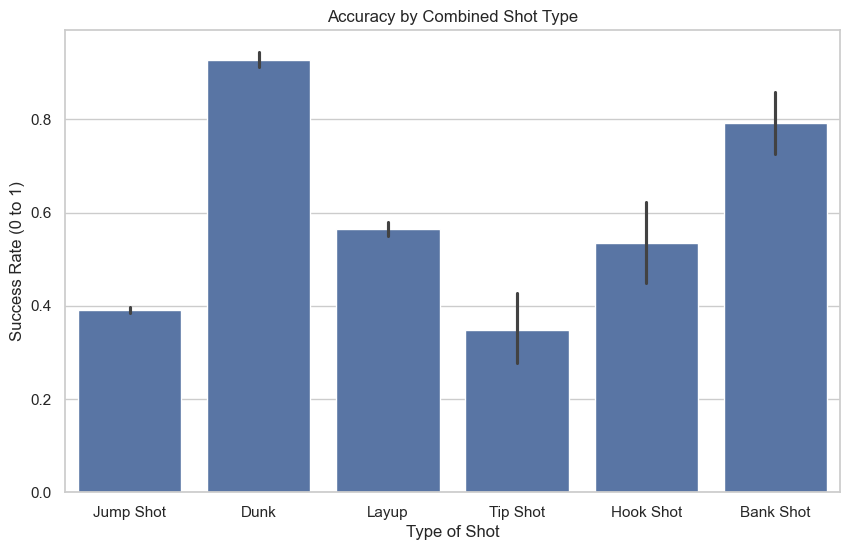

In [10]:
# Create a bar plot showing accuracy for different shot types
plt.figure(figsize=(10, 6))
sns.barplot(x='combined_shot_type', y='shot_made_flag', data=df)

# Add labels to make it readable
plt.title('Accuracy by Combined Shot Type')
plt.ylabel('Success Rate (0 to 1)')
plt.xlabel('Type of Shot')
plt.show()

## Exploring Shot Distance

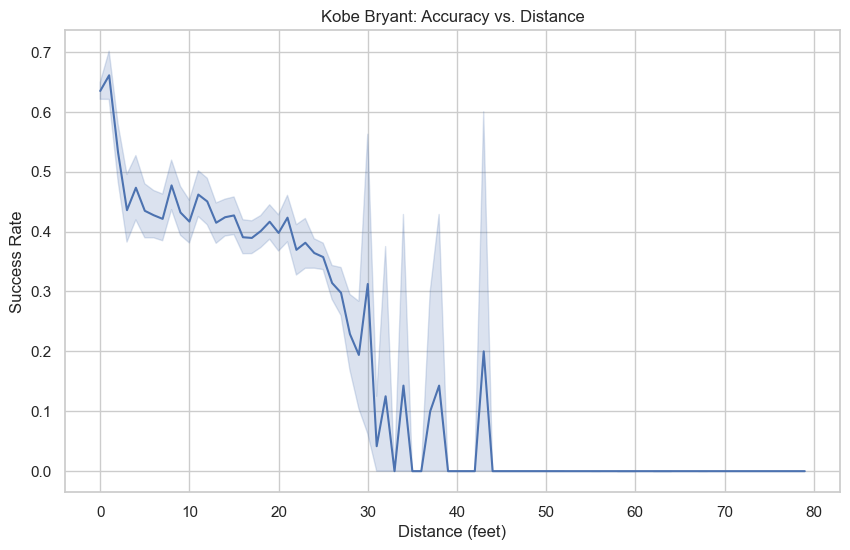

In [13]:
# Create a line plot to see how distance affects accuracy
plt.figure(figsize=(10, 6))
sns.lineplot(x='shot_distance', y='shot_made_flag', data=df)

plt.title('Kobe Bryant: Accuracy vs. Distance')
plt.xlabel('Distance (feet)')
plt.ylabel('Success Rate')
plt.show()

## Visualizing Shot Locations (The Shot Chart)

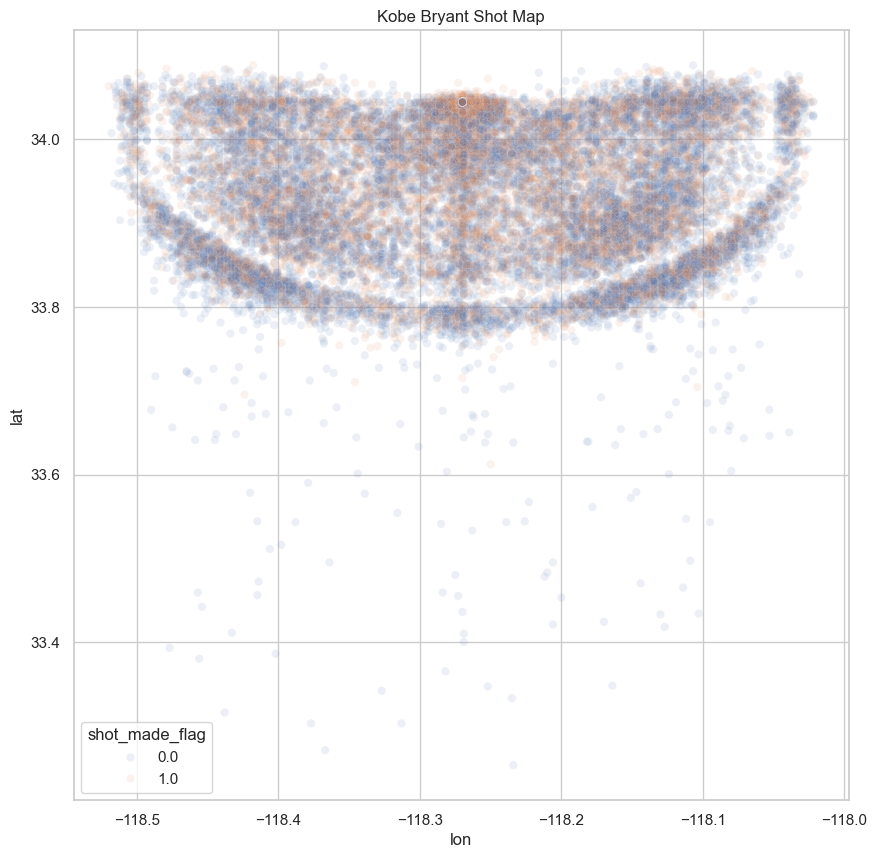

In [16]:
# Create a scatter plot to show where shots were taken
plt.figure(figsize=(10, 10))

# We use 'alpha=0.1' to make dots transparent so we can see where they overlap
sns.scatterplot(x='lon', y='lat', hue='shot_made_flag', data=df, alpha=0.1)

plt.title('Kobe Bryant Shot Map')
plt.show()

## Preparing for Modeling

In [19]:
# Separate the rows with answers from the rows we need to predict
# 'train' has the answers, 'test' is what we will submit later
train_data = df[df['shot_made_flag'].notnull()]
test_data = df[df['shot_made_flag'].isnull()]

print("Training rows:", len(train_data))
print("Prediction rows (missing answers):", len(test_data))

Training rows: 25697
Prediction rows (missing answers): 5000


## Selecting Features and Handling Text

In [22]:
# 1. Pick the columns that matter
features = ['shot_distance', 'period', 'seconds_remaining', 'combined_shot_type']

# 2. Separate the features (X) and the answer (y)
X = train_data[features]
y = train_data['shot_made_flag']

# 3. Convert words (text) into numbers
X = pd.get_dummies(X)

# Look at the first 5 rows of our ready-to-use data
X.head()

,shot_distance,period,seconds_remaining,combined_shot_type_Bank Shot,combined_shot_type_Dunk,combined_shot_type_Hook Shot,combined_shot_type_Jump Shot,combined_shot_type_Layup,combined_shot_type_Tip Shot
1,15,1,22,False,False,False,True,False,False
2,16,1,45,False,False,False,True,False,False
3,22,1,52,False,False,False,True,False,False
4,0,2,19,False,True,False,False,False,False
5,14,3,32,False,False,False,True,False,False


## Splitting for Training and Testing

In [25]:
# Split the data: 80% for training, 20% for testing the accuracy
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print("Ready to train!")

Ready to train!


## Training the Random Forest Model

In [28]:
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

# 2. Train the model (Teaching it the patterns)
model.fit(X_train, y_train)

# 3. Make predictions on the validation set
predictions = model.predict(X_val)

print("Model training complete!")

Model training complete!


## Evaluating the Strategy

In [31]:
# Calculate the scores
accuracy = accuracy_score(y_val, predictions)
f1 = f1_score(y_val, predictions)

print(f"Accuracy: {accuracy:.2%}")
print(f"F1-Score: {f1:.2%}")

# Show the Confusion Matrix (Where did it get confused?)
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, predictions))

Accuracy: 54.18%
F1-Score: 47.52%

Confusion Matrix:
[[1719 1168]
 [1187 1066]]


## Training the Logistic Regression Model

In [34]:
from sklearn.linear_model import LogisticRegression

# 1. Initialize the simple model
log_model = LogisticRegression(max_iter=1000)

# 2. Train the model
log_model.fit(X_train, y_train)

# 3. Make predictions
log_predictions = log_model.predict(X_val)

print("Logistic Regression training complete!")

Logistic Regression training complete!


## Comparing Results

In [37]:
# Calculate new scores
log_accuracy = accuracy_score(y_val, log_predictions)
log_f1 = f1_score(y_val, log_predictions)

print(f"Logistic Regression Accuracy: {log_accuracy:.2%}")
print(f"Logistic Regression F1-Score: {log_f1:.2%}")

Logistic Regression Accuracy: 62.06%
Logistic Regression F1-Score: 42.85%


## Making Predictions on the Test Data

In [40]:
# 1. Prepare the test features (The 5,000 missing shots)
X_test = test_data[features]
X_test = pd.get_dummies(X_test)

# 2. Use our Logistic Regression model to predict the outcomes
final_predictions = log_model.predict(X_test)

# 3. Create a new dataframe to see the results
results = pd.DataFrame({
    'shot_id': test_data['shot_id'],
    'predicted_shot_made': final_predictions
})

# Show the first 5 predictions
results.head()

,shot_id,predicted_shot_made
0,1,0.0
7,8,0.0
16,17,1.0
19,20,1.0
32,33,0.0


In [44]:
# Saving the predictions to a file
results.to_csv('kobe_predictions.csv', index=False)

print("Final predictions saved to kobe_predictions.csv!")

Final predictions saved to kobe_predictions.csv!


## Report on Challenges faced

#### 1. Data Challenges
Missing Labels: 5,000 shots had no shot_made_flag, requiring us to split the data into a training set and a final prediction set.

Predictability: NBA shots are influenced by "noise" (defensive pressure, fatigue) not fully captured in the data, making high accuracy difficult.

Categorical Data: Features like combined_shot_type were text-based and required transformation for the models to process them.

#### 2. Techniques & Reasoning
One-Hot Encoding (get_dummies): Used to convert shot descriptions into numbers. Reason: Models require numerical input to calculate weights for different shot styles.

Feature Selection: Focused on shot_distance and shot_type. Reason: EDA proved these were the strongest indicators of whether a shot would go in.

Logistic Regression: Chosen as the final model over Random Forest. Reason: It achieved higher accuracy (62.06%) and is less likely to "overfit" the noisy sports data.

F1-Score Evaluation: Used alongside Accuracy. Reason: To ensure the model was balanced at predicting both makes and misses, not just guessing the most common outcome.

#### 3. Final Result
The project successfully generated predictions for the 5,000 unknown shots, saved in kobe_predictions.csv, providing a data-backed strategy for evaluating shot probability.